# Continuous Wavelet Transform Analysis

This section reproduces the analysis up to Figure 1′: Autocorrelations using continuous wavelet transform instead of discrete wavelet transform.

In [1]:
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.style.use('seaborn-v0_8')
%matplotlib inline

from scipy.signal import fftconvolve

def covariance_fft(x):
    x = x - np.mean(x)
    c = fftconvolve(x, x[::-1], mode='full')
    c = c[c.size//2:]
    return c / c[0]

In [2]:


DATA_PATH = "SandP_log2min.dat"   # one value per row

# Try reading with header; if no header, fallback
try:
    df = pd.read_csv(DATA_PATH)
    if df.shape[1] == 1:
        df.columns = ['price']
except:
    df = pd.read_csv(DATA_PATH, header=None)
    df.columns = ['price']

df = df.dropna().reset_index(drop=True)

# Log-price
df['log_price'] = np.log(df['price'])

def deseasonalize(log_price, samples_per_day):
    """Remove intraday mean log-return pattern."""
    returns = np.diff(log_price)
    n = len(returns)
    
    # average return at each intraday position
    intraday_idx = np.arange(n) % samples_per_day
    seasonal = np.array([
        returns[intraday_idx == i].mean() 
        for i in range(samples_per_day)
    ])
    
    # subtract seasonal mean at each time step
    returns_ds = returns - seasonal[intraday_idx]
    
    # reconstruct log-price
    return np.cumsum(np.r_[0, returns_ds])

samples_per_day = 195  # 6.5 hours × 30 two-minute bars

# Since there is no intraday pattern, we skip deseasonalization
df['log_price_deseason'] = df['log_price'] #deseasonalize(df['log_price'], samples_per_day)

df.head()



,price,log_price,log_price_deseason
0,9.710267,2.273184,2.273184
1,9.710085,2.273165,2.273165
2,9.709599,2.273115,2.273115
3,9.709478,2.273103,2.273103
4,9.709296,2.273084,2.273084


In [3]:
wavelet = 'gaus1'
max_level = 10
# scales = 2**np.arange(1, max_level+1)
scales = np.linspace(1, 1024, 25)
log_price = np.array(df['log_price_deseason'].values)

# CWT
coeffs, _ = pywt.cwt(log_price, scales, wavelet)
detail_series = coeffs  # shape: (n_scales, n_time)

increments = np.diff(log_price)
shuffled = np.random.permutation(increments)
log_price_null = np.cumsum(np.r_[0, shuffled])

coeffs_sh, _ = pywt.cwt(log_price_null, scales, wavelet)

print("scales: ", scales)
print("detail_series shape:", detail_series.shape)

scales:  [1.00000e+00 4.36250e+01 8.62500e+01 1.28875e+02 1.71500e+02 2.14125e+02
 2.56750e+02 2.99375e+02 3.42000e+02 3.84625e+02 4.27250e+02 4.69875e+02
 5.12500e+02 5.55125e+02 5.97750e+02 6.40375e+02 6.83000e+02 7.25625e+02
 7.68250e+02 8.10875e+02 8.53500e+02 8.96125e+02 9.38750e+02 9.81375e+02
 1.02400e+03]
detail_series shape: (25, 640533)


In [ ]:
# window = 50  # window for local volatility

# vol_series = []
# for s_idx in range(len(scales)):
#     d = detail_series[s_idx]
#     sq = d**2
#     vol = np.sqrt(pd.Series(sq).rolling(window, min_periods=1).mean().values)
#     vol_series.append(vol)

# vol_series = np.array(vol_series)
# log_vol_series = np.log(vol_series + 1e-12)

# # Choose a scale index for ~20 min
# scale_idx_20m = 5
# w_a = log_vol_series[scale_idx_20m]
# w_a_centered = w_a - np.mean(w_a)
# v_a = np.cumsum(w_a_centered)

# print("Length of v_a:", len(v_a))

Length of v_a: 640533


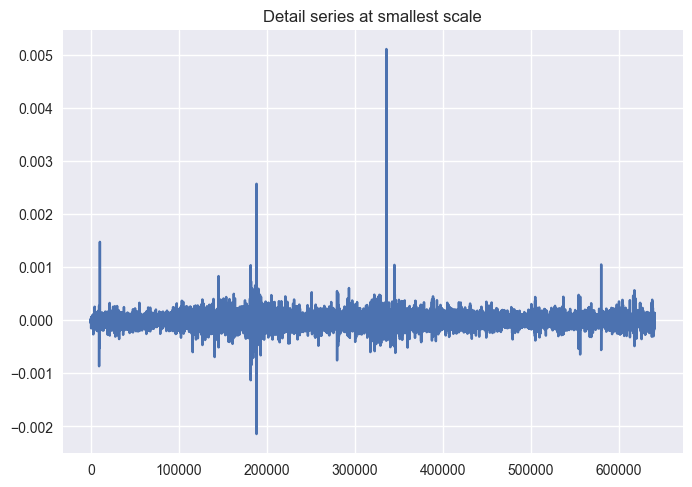

In [4]:
ind = 0
plt.plot(detail_series[ind][100:-10])
plt.title('Detail series at smallest scale')
plt.show()


## Figure 1 (CWT): log-price, centered log-volatility walk, shuffled version

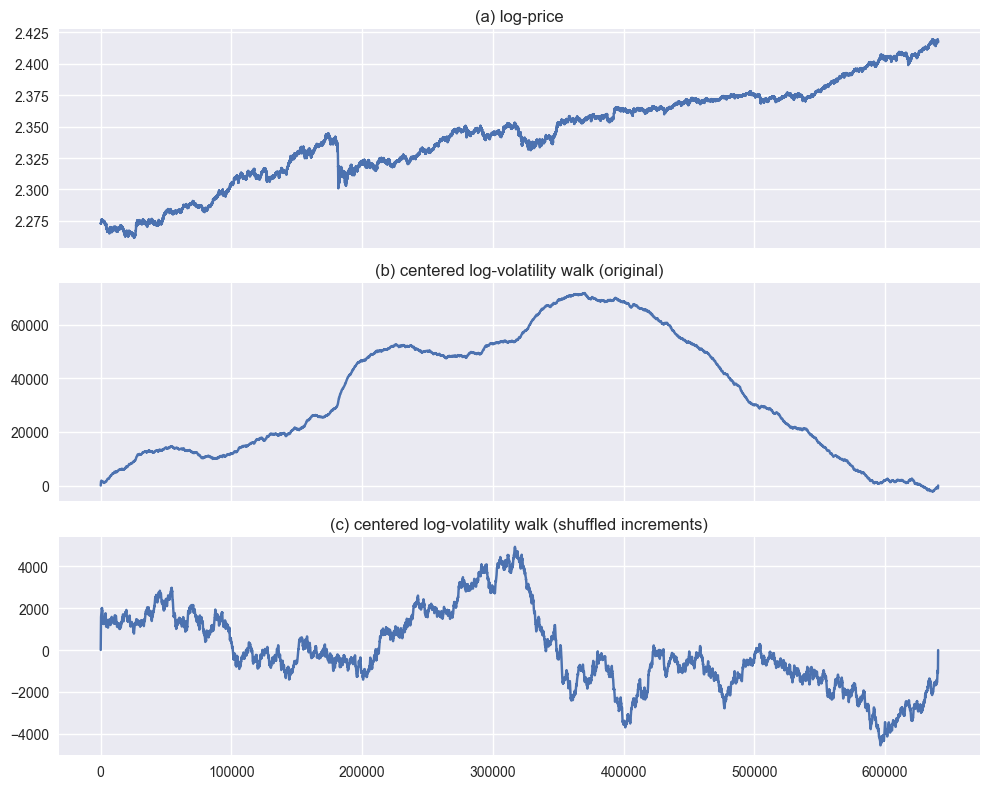

In [ ]:
# # (a) log-price
# t = np.arange(len(df))
# logP = df['log_price_deseason'].values

# # (c) shuffled increments version
# increments = np.diff(logP)
# shuffled_increments = np.random.permutation(increments)
# logP_shuffled = np.concatenate([[logP[0]], logP[0] + np.cumsum(shuffled_increments)])

# # Recompute CWT for shuffled series
# coeffs_sh, _ = pywt.cwt(logP_shuffled, scales, wavelet)
# detail_series_sh = coeffs_sh

# vol_series_sh = []
# for s_idx in range(len(scales)):
#     d = detail_series_sh[s_idx]
#     sq = d**2
#     vol = np.sqrt(pd.Series(sq).rolling(window, min_periods=1).mean().values)
#     vol_series_sh.append(vol)
# vol_series_sh = np.array(vol_series_sh)
# log_vol_series_sh = np.log(vol_series_sh + 1e-12)

# w_a_sh = log_vol_series_sh[scale_idx_20m]
# w_a_sh_centered = w_a_sh - np.mean(w_a_sh)
# v_a_sh = np.cumsum(w_a_sh_centered)

# fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
# axes[0].plot(t, logP)
# axes[0].set_title('(a) log-price')

# axes[1].plot(t, v_a)
# axes[1].set_title('(b) centered log-volatility walk (original)')

# axes[2].plot(t, v_a_sh)
# axes[2].set_title('(c) centered log-volatility walk (shuffled increments)')

# plt.tight_layout()
# plt.show()

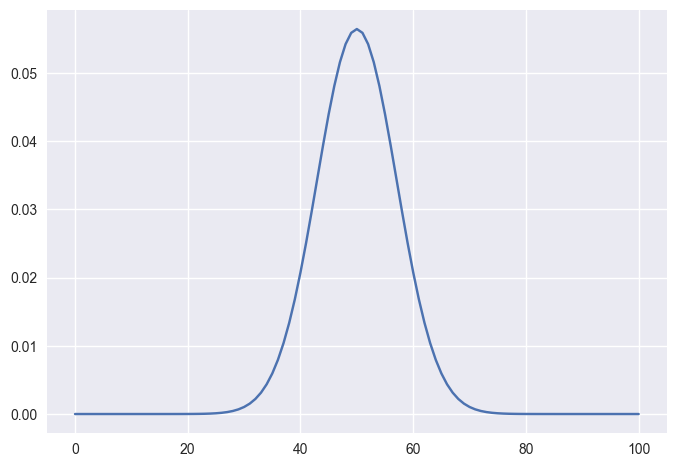

In [7]:
kernel_support = 5  # in units of "a" (tune this)
u = np.linspace(-kernel_support, kernel_support, 2*kernel_support*10 + 1)
phi = np.exp(-u**2)          # example bump (Gaussian-like)
phi = phi / phi.sum()        # ||φ||₁ ≈ 1 in discrete sense

plt.plot(phi)
plt.show()

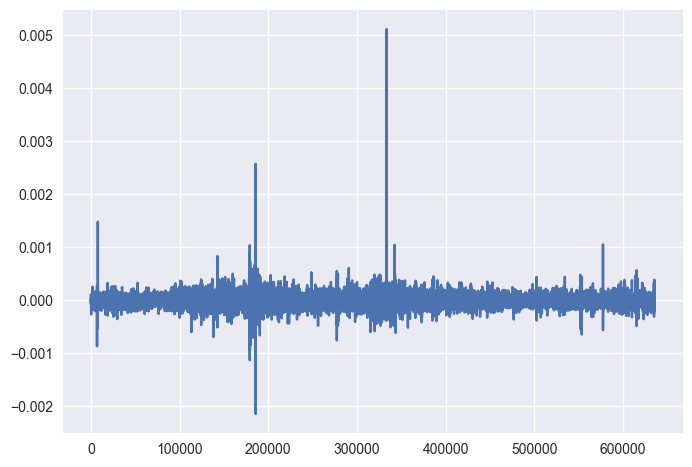

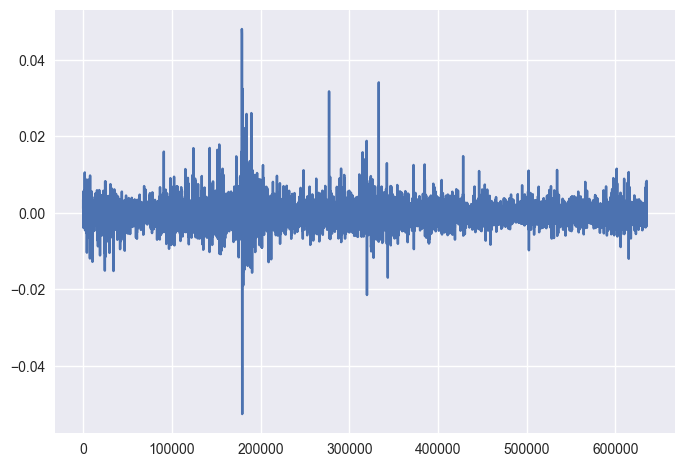

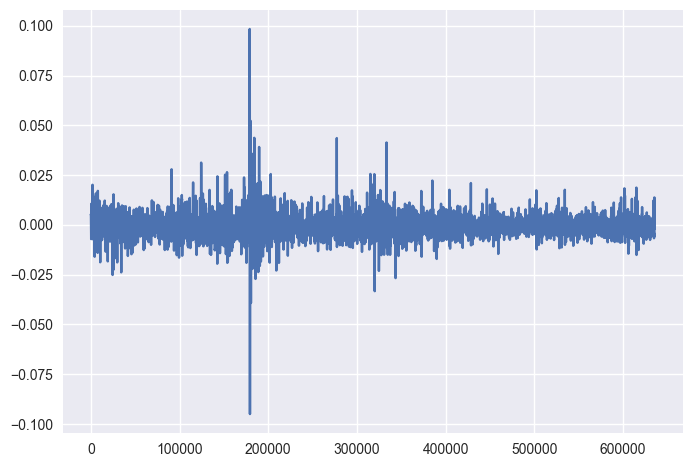

In [5]:
for a_idx, a in enumerate(scales[::10]):
    plt.plot(coeffs[a_idx][2500:-2500])
    plt.show()

In [6]:
from scipy.signal import convolve

def compute_omega_centered(coeffs,boundaries=2500):
    alpha = -2.0  # or the value you want (paper uses a nonzero exponent tied to ζ(2))
    kernel_support =5
    sigma2_raw = []

    for a_idx, a in enumerate(scales):
        Wa = coeffs[a_idx][boundaries:-boundaries]                   # shape (n_times,)
        energy = np.abs(Wa)**2            # |Tψ(b,a)|²

        # rescale kernel to scale a
        # effective width in indices ≈ a * base_support
        width = 10
        u = np.linspace(-1, 1, 2*width + 1)
        phi_a = np.exp(-u**2)
        phi_a = phi_a / phi_a.sum()       # ||φ_a||₁ ≈ 1

        smoothed = convolve(energy, phi_a, mode='same')

        
        sigma2_a = (a**alpha) * smoothed
        sigma2_raw.append(sigma2_a)
    # For each scale, the invalid region is trim = 3*width
    trims = [3 * max(3, int(kernel_support * a)) for a in scales]

    left_trim  = max(trims)
    right_trim = max(trims)
    sigma2 = np.array([s[left_trim:-right_trim] for s in sigma2_raw])  # shape (n_scales, n_times)
    omega = np.log(np.sqrt(sigma2) + 1e-12)
    omega_centered = []
    for o in sigma2:
        lo=np.log(np.sqrt(o) + 1e-12)
        omega_centered.append(lo - np.mean(lo))
    return omega_centered

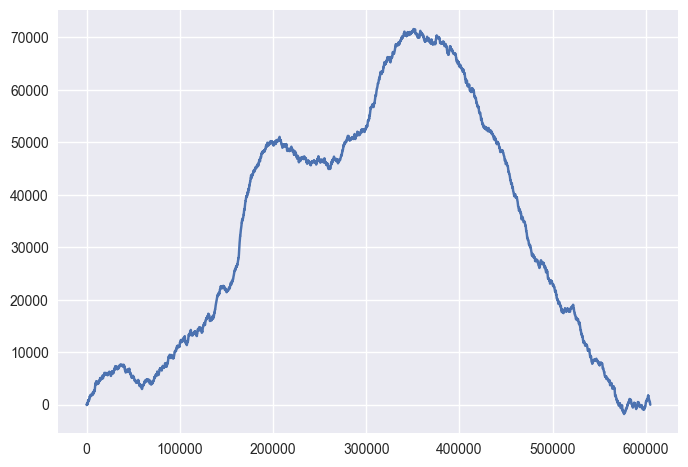

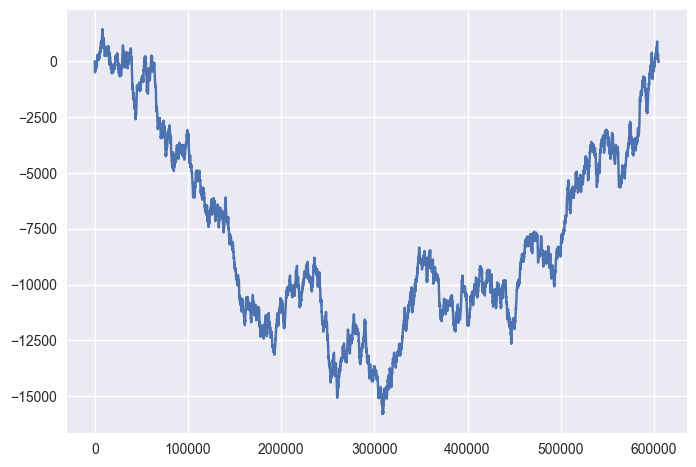

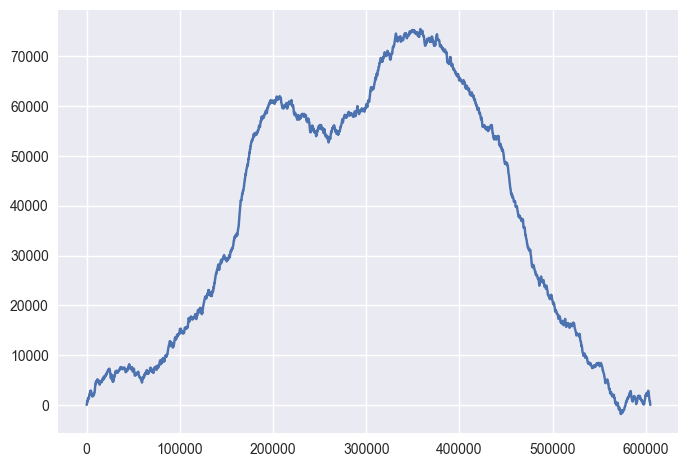

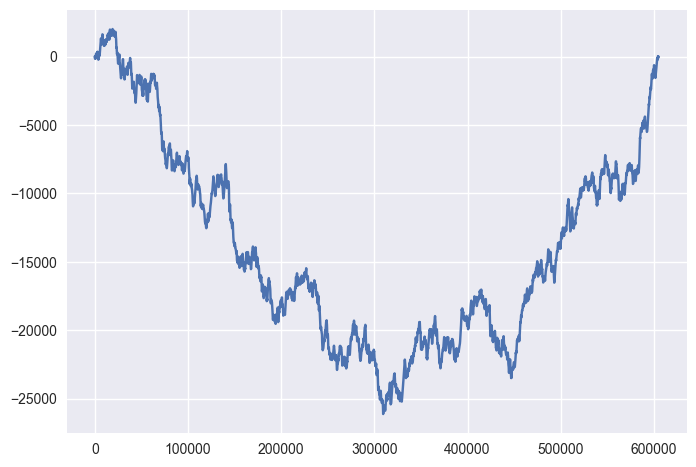

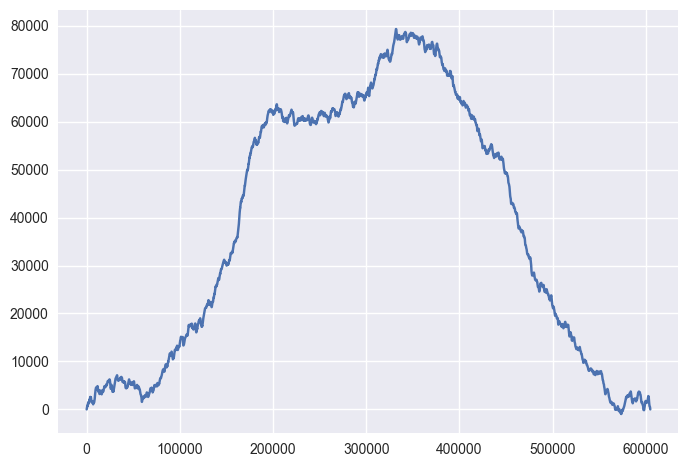

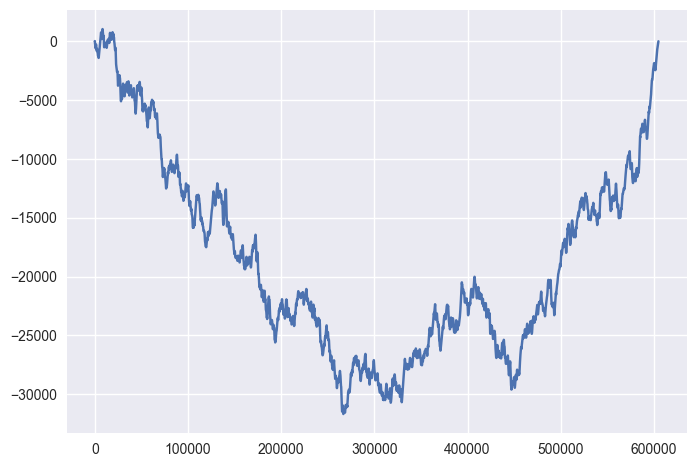

In [7]:
omega_centered = compute_omega_centered(coeffs)
omega_centered_random = compute_omega_centered(coeffs_sh)
for i in [3,6,9]:
    plt.plot(np.cumsum(omega_centered[i]))
    plt.show()
    plt.plot(np.cumsum(omega_centered_random[i]))
    plt.show()

In [ ]:
# t = np.arange(len(log_price))
# fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=False)
# axes[0].plot(t, log_price)
# axes[0].set_title('(a) log-price')

# axes[1].plot(np.arange(len(omega_centered)), omega_centered)
# axes[1].set_title('(b) centered log-volatility walk (original)')

# axes[2].plot(np.arange(len(log_price_null)), log_price_null)
# axes[2].set_title('(c)log price reconstructed from shuffled increments')

# axes[3].plot(np.arange(len(omega_centered_random)), omega_centered_random)
# axes[3].set_title('(c) centered log-volatility walk (shuffled increments)')

# plt.tight_layout()
# plt.show()

KeyboardInterrupt: 

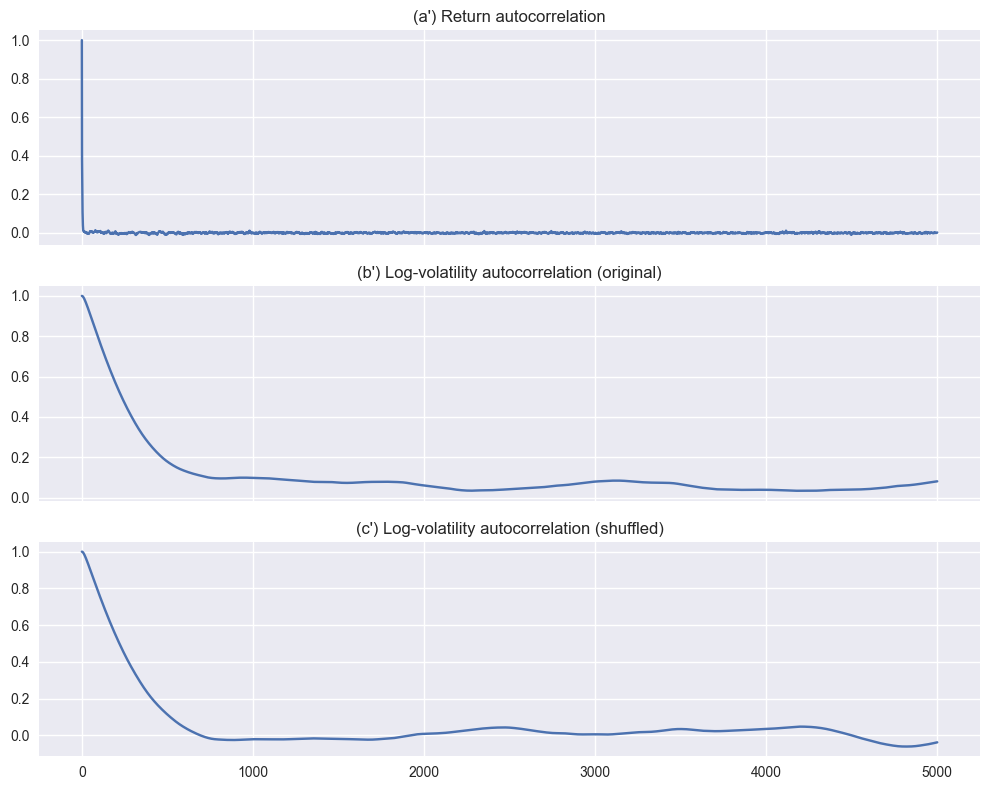

In [9]:
max_lag = 5000
ind = 10
# (a′) return autocorrelation
ret = np.diff(df['log_price_deseason'].values)
ret_ac = covariance_fft(ret)

# (b′) log-volatility autocorrelation (original)
w = omega_centered[ind]
w_ac = covariance_fft(w)

# (c′) log-volatility autocorrelation (shuffled)
w_sh = omega_centered_random[ind]
w_sh_ac = covariance_fft(w_sh)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True,)
axes[0].plot(ret_ac[:max_lag+1])
axes[0].set_title("(a') Return autocorrelation")

axes[1].plot(w_ac[:max_lag+1])
axes[1].set_title("(b') Log-volatility autocorrelation (original)")

axes[2].plot(w_sh_ac[:max_lag+1])
axes[2].set_title("(c') Log-volatility autocorrelation (shuffled)")

plt.tight_layout()
plt.show()

## Figure 1′ (CWT): Autocorrelations

In [28]:
max_lag = 500

# (a′) return autocorrelation
ret = np.diff(df['log_price_deseason'].values)
ret_ac = covariance_fft(ret)

# (b′) log-volatility autocorrelation (original)
w = w_a
w_ac = covariance_fft(w)

# (c′) log-volatility autocorrelation (shuffled)
w_sh = w_a_sh
w_sh_ac = covariance_fft(w_sh)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(ret_ac[:max_lag+1])
axes[0].set_title("(a') Return autocorrelation")

axes[1].plot(w_ac[:max_lag+1])
axes[1].set_title("(b') Log-volatility autocorrelation (original)")

axes[2].plot(w_sh_ac[:max_lag+1])
axes[2].set_title("(c') Log-volatility autocorrelation (shuffled)")

plt.tight_layout()
plt.show()

NameError: name 'w_a' is not defined

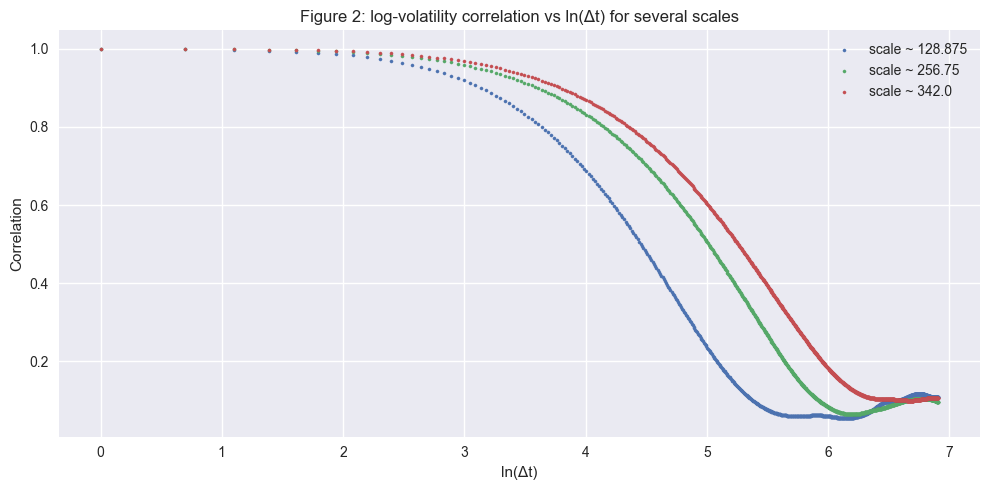

In [10]:
def corr_function(x, max_lag):
    """
    Normalized autocorrelation function C(Δt) for a 1D series x,
    for lags 0..max_lag.
    """
    x = np.asarray(x, float)
    n = len(x)

    # raw autocovariance via FFT convolution
    c = covariance_fft(x)

    # unbiased normalization by number of overlapping points
    norm = np.arange(n, 0, -1)
    c = c / norm

    # normalize to get correlation function: C(0) = 1
    c = c / c[0]

    return c[:max_lag + 1]

# Choose a few scale indices (adjust depending on your sampling)
scale_indices = [3, 6, 8]  # example: smaller, medium, larger scales
labels = [f'scale ~ {scales[i]}' for i in scale_indices]

max_lag_fig2 = 1000
lags = np.arange(1, max_lag_fig2+1)

plt.figure(figsize=(10, 5))
for idx, lab in zip(scale_indices, labels):
    w_s = omega_centered[idx]          # this is ω_a(t)
    C = corr_function(w_s,max_lag_fig2)
    # skip lag 0, plot Δt = 1..max_lag
    plt.scatter(np.log(lags), C[1:], s=5, label=lab)

plt.xlabel('ln(Δt)')
plt.ylabel('Correlation')
plt.title('Figure 2: log-volatility correlation vs ln(Δt) for several scales')
plt.legend()
plt.tight_layout()
plt.show()


525
Progress: 1/525
Progress: 11/525
Progress: 21/525
Progress: 31/525
Progress: 41/525
Progress: 51/525
Progress: 61/525
Progress: 71/525
Progress: 81/525
Progress: 91/525
Progress: 101/525
Progress: 111/525
Progress: 121/525
Progress: 131/525
Progress: 141/525
Progress: 151/525
Progress: 161/525
Progress: 171/525
Progress: 181/525
Progress: 191/525
Progress: 201/525
Progress: 211/525
Progress: 221/525
Progress: 231/525
Progress: 241/525
Progress: 251/525
Progress: 261/525
Progress: 271/525
Progress: 281/525
Progress: 291/525
Progress: 301/525
Progress: 311/525
Progress: 321/525
Progress: 331/525
Progress: 341/525
Progress: 351/525
Progress: 361/525
Progress: 371/525
Progress: 381/525
Progress: 391/525
Progress: 401/525
Progress: 411/525
Progress: 421/525
Progress: 431/525
Progress: 441/525
Progress: 451/525
Progress: 461/525
Progress: 471/525
Progress: 481/525
Progress: 491/525
Progress: 501/525
Progress: 511/525
Progress: 521/525


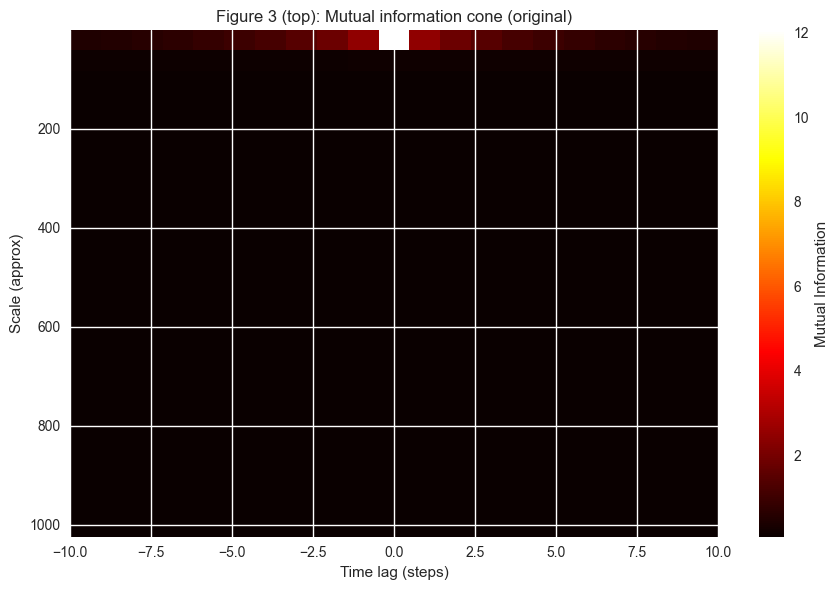

In [11]:
import numpy as np
from sklearn.feature_selection import mutual_info_regression
import multiprocess as mp

# -----------------------------
# 1. Precompute centered series
# -----------------------------
max_time_lag = 10
ref_idx = 0  # smallest scale as reference

w_a_centered_list = omega_centered#[log_vol - np.mean(log_vol) for log_vol in log_vol_series]
w_ref = w_a_centered_list[ref_idx]

I_map = np.zeros((len(scales), 2*max_time_lag+1))

# -----------------------------
# 2. Worker function
# -----------------------------
def compute_I(args):
    """
    args = (s_idx, dt, w_a_centered_list, w_ref)
    Everything is passed explicitly so workers don't rely on notebook globals.
    """
    import numpy as np
    from sklearn.feature_selection import mutual_info_regression

    s_idx, dt, w_list, w_ref_local = args

    w_other = w_list[s_idx]

    # Align time series depending on lag
    if dt >= 0:
        x = w_other[:-dt or None]
        y = w_ref_local[dt:]
    else:
        x = w_other[-dt:]
        y = w_ref_local[:dt or None]

    # Too short → skip
    if len(x) < 10:
        return 0.0

    # Compute MI
    I = mutual_info_regression(x.reshape(-1,1), y, n_jobs=1)
    return float(I[0])

# -----------------------------
# 3. Build task list
# -----------------------------
tasks = [
    (s_idx, dt, w_a_centered_list, w_ref)
    for s_idx in range(len(scales))
    for dt in range(-max_time_lag, max_time_lag+1)
]
print(len(tasks))
# -----------------------------
# 4. Run multiprocessing
# -----------------------------
results = []
with mp.Pool(mp.cpu_count()) as pool:
    for i, result in enumerate(pool.imap(compute_I, tasks)):
        results.append(result)
        if i%10==0:
            print(f"Progress: {i + 1}/{len(tasks)}")

# -----------------------------
# 5. Fill I_map
# -----------------------------
for i, (s_idx, dt, _, _) in enumerate(tasks):
    I_map[s_idx, dt + max_time_lag] = results[i]

    

plt.figure(figsize=(9, 6))
extent = [-max_time_lag, max_time_lag, scales[-1], scales[0]]
plt.imshow(I_map, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (top): Mutual information cone (original)')
plt.tight_layout()
plt.show()


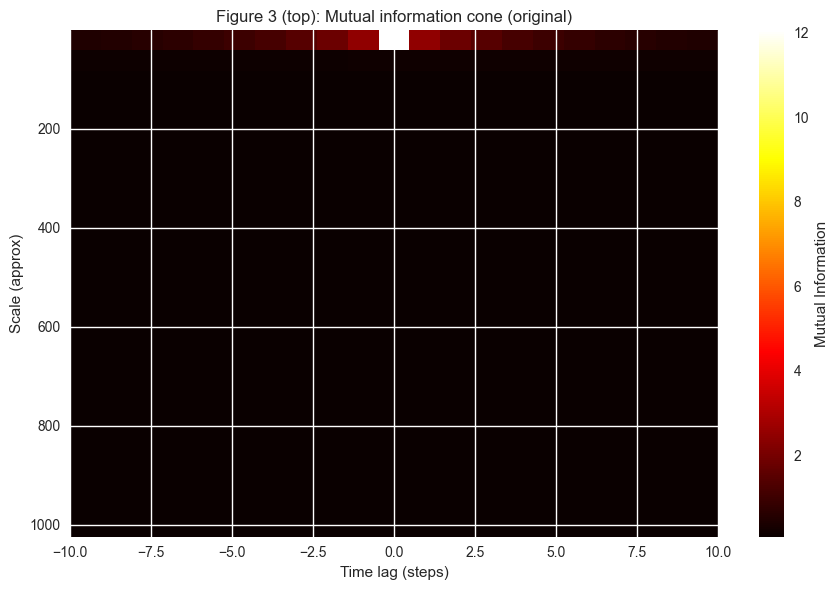

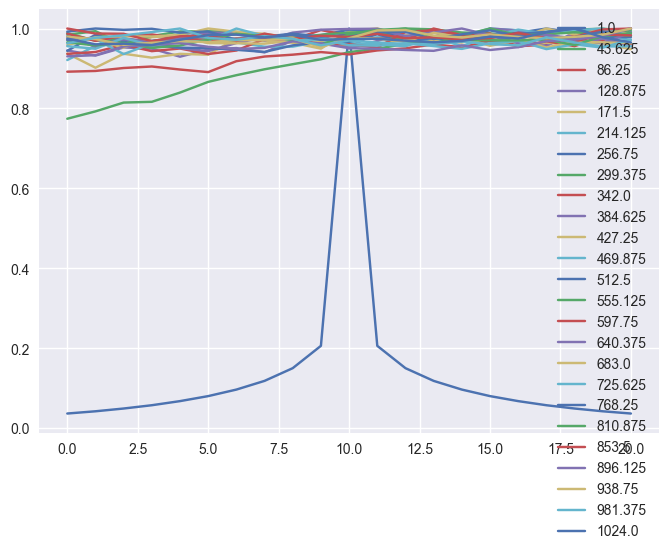

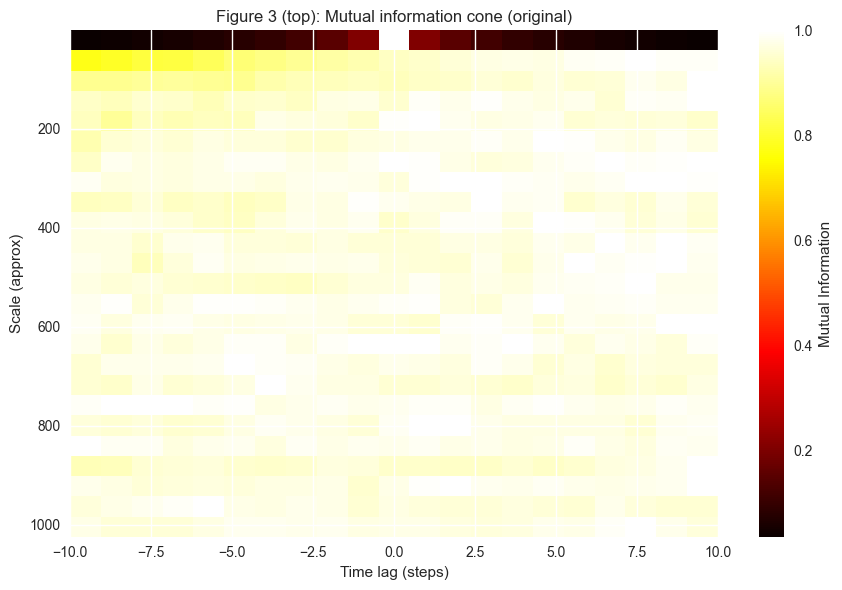

In [12]:

plt.figure(figsize=(9, 6))
extent = [-max_time_lag, max_time_lag, scales[-1], scales[0]]
plt.imshow(I_map, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (top): Mutual information cone (original)')
plt.tight_layout()
plt.show()


I_normalized = []
for i,I in enumerate(I_map):
    I_normalized.append(I/np.max(I))
    plt.plot(I_normalized[i],label=scales[i])

plt.legend()
plt.show()
plt.figure(figsize=(9, 6))
extent = [-max_time_lag, max_time_lag, scales[-1], scales[0]]
plt.imshow(I_normalized, aspect='auto', origin='upper', cmap='hot', extent=extent)
plt.colorbar(label='Mutual Information')
plt.xlabel('Time lag (steps)')
plt.ylabel('Scale (approx)')
plt.title('Figure 3 (top): Mutual information cone (original)')
plt.tight_layout()
plt.show()

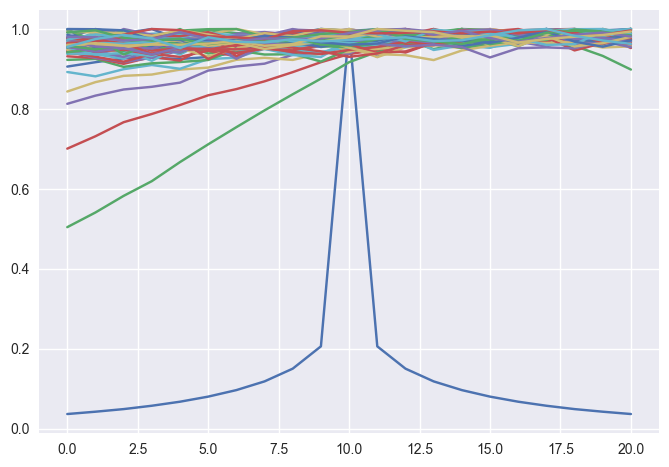

In [26]:
for i in I_map:
    plt.plot(i/np.max(i))
plt.show()